In [ ]:
import marimo as mo

# tcren · pMHC surface topography

A contact potential scores an interface that already exists. This describes the pMHC
**before** a TCR arrives: the peptide sits in a groove between two helices, and a TCR
coming down from above meets *one* surface. So the descriptor is a height field
$h(x, y)$ over that groove, with chemistry painted on.

| channel | what a cell holds |
|---|---|
| `h` | **elevation** — height of the solvent-accessible surface above the groove floor (Å) |
| `phobic` | **hydropathy** of the residue that surface belongs to (Kyte–Doolittle, or the axis recovered from the MJ matrix) |
| `charge` | formal side-chain charge at pH 7 (His counted as +0.1, since its pKa sits near it) |

Method follows [SURFMAP](https://doi.org/10.1021/acs.jcim.1c01269) — surface shell,
per-cell feature, 8-neighbour smoothing, Manhattan map distance — and
[Protein Surface Topography](https://doi.org/10.1074/jbc.RA119.010494) for centring the
chart on the functional site. A **flat** raster rather than SURFMAP's equal-area spherical
chart, because a TCR-facing pMHC surface is an open, near-planar patch and a plane does not
distort it.

Two conventions worth stating, because both were bugs first:

* the frame is **refit from every structure** — *z* from the groove-floor plane normal,
  *y* from the **peptide** (the floor's own principal axis is not the groove axis), origin
  on the peptide centroid — so maps compare without prealigning the inputs;
* heights come from **ray casting in that frame**, not from Shrake–Rupley surface points,
  which are sampled on a sphere fixed in global axes and so move when the input is rotated.

In [ ]:
from pathlib import Path

import numpy as np
import polars as pl

from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc
from tcren.structure import parse_structure
from tcren.surface import (
    SOURCE_CODES,
    surface_distance,
    surface_map,
    surface_stats,
    surface_table,
)

REPO = Path(__file__).resolve().parents[1]
CANON = REPO / "data" / "Canonical2026"

In [ ]:
def load(pdb_id):
    """Parse, chain-type and MHC-annotate one Canonical2026 complex."""
    for cand in (CANON / f"{pdb_id}.pdb.gz", CANON / f"{pdb_id}.pdb"):
        if cand.exists():
            s = parse_structure(cand, pdb_id=pdb_id)
            classify_chains(s, organism="human", autodetect_species=True)
            annotate_mhc(s)
            return s
    raise FileNotFoundError(f"{pdb_id} not in {CANON}; run `tcren fetch-data`")

def mapped(pdb_id, **kw):
    return surface_map(load(pdb_id), **kw)

## The named epitopes

Two the literature calls **featureless**, two it calls **bulged**, and one in between.
These are the reference points the descriptor has to get right.

In [ ]:
#: pdb_id -> (epitope, label, citation). All present in Canonical2026.
CASES = {
    "1oga": ("GILGFVFTL", "featureless", "influenza M1, HLA-A*02:01 — Song 2017 NSMB, "
                                         "'relatively featureless'"),
    "4mji": ("TAFTIPSI", "featureless", "HIV RT 8-mer, HLA-B*51:01 — Motozono 2014 J Immunol, "
                                        "'relatively featureless'"),
    "1ao7": ("LLFGYPVYV", "intermediate", "HTLV-1 Tax, HLA-A*02:01 — prominent but "
                                          "partly buried P5-Tyr"),
    "2ak4": ("LPEPLPQGQLTAY", "bulged", "EBV BZLF1 13-mer, HLA-B*35:08 — Tynan 2007 Nat "
                                        "Immunol, 'bulged'"),
    "2nx5": ("EPLPQGQLTAY", "bulged", "EBV BZLF1 11-mer, HLA-B*35:01 — highly bulged, "
                                      "7 side chains solvent-exposed"),
}

In [ ]:
maps = {pid: mapped(pid) for pid in CASES}

In [ ]:
channel = mo.ui.dropdown(
    options=["h", "phobic", "charge"], value="h", label="channel",
)
grid_n = mo.ui.slider(16, 96, value=64, step=8, label="grid rows (along the groove)")
smooth = mo.ui.checkbox(value=True, label="8-neighbour smoothing")
mo.hstack([channel, grid_n, smooth], justify="start", gap=2)

<marimo-slider data-initial-value='64' data-label='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003egrid rows (along the groove)\u003c/span\u003e\u003c/span\u003e"' data-start='16' data-stop='96' data-step='8' data-steps='[]' data-debounce='false' data-disabled='false' data-orientation='"horizontal"' data-show-value='false' data-include-input='false' data-full-width='false'>

## Elevation, charge and hydropathy, side by side

One shared colour scale per row, so the panels are comparable rather than each
auto-scaled to its own range — the whole point is the difference between them.
Peptide-owned cells are outlined; everything else is MHC helix or groove floor.

In [ ]:
import matplotlib.pyplot as plt

# Shared style: no gridlines competing with the raster, small type, tight panels.
PANEL_KW = dict(interpolation="nearest", origin="lower", aspect="equal")
LABEL_KW = dict(fontsize=7)
#: Å window actually drawn. The full map extent is wide enough for a class-II 15-mer with
#: flanks; cropping to the groove itself stops the peptide being a sliver in the middle.
VIEW = (-16.0, 16.0, -16.0, 16.0)

In [ ]:
def draw_map(ax, smap, chan, vmin, vmax, cmap, source_codes, outline=True):
    """One channel of one map, cropped to the groove, with the peptide footprint outlined."""
    x0, x1, y0, y1 = smap.extent
    im = ax.imshow(smap.channels[chan], extent=(x0, x1, y0, y1), vmin=vmin, vmax=vmax,
                   cmap=cmap, **PANEL_KW)
    if outline:
        # contour() honours `extent` only alongside `origin`; without both it silently draws
        # in array-index coordinates and the outline lands nowhere near the surface.
        ax.contour((smap.source == source_codes["peptide"]).astype(float), levels=[0.5],
                   colors="k", linewidths=1.0, extent=(x0, x1, y0, y1), origin="lower")
    ax.set_xlim(VIEW[0], VIEW[1])
    ax.set_ylim(VIEW[2], VIEW[3])
    ax.tick_params(labelsize=6)
    return im

def limits(maps, chan):
    """Shared colour range: zero-centred for signed channels, percentile for elevation."""
    vals = np.concatenate([m.channels[chan][np.isfinite(m.channels[chan])] for m in maps])
    if chan in ("phobic", "charge"):
        lim = float(np.nanpercentile(np.abs(vals), 98)) or 1.0
        return -lim, lim, "RdBu_r"
    return (float(np.nanpercentile(vals, 2)), float(np.nanpercentile(vals, 98)), "viridis")

def cross_profile(smap, source_codes, band=8.0):
    """Elevation across the groove, averaged over the peptide's own y-band.

    This is the panel that makes the comparison legible: the heatmaps are dominated by the two
    MHC helices, which are the tallest thing in every structure whatever the peptide does.
    A cut across them shows directly whether the peptide sits in the valley between the rails
    or rides above it.
    """
    n_y, n_x = smap.grid
    x0, x1, y0, y1 = smap.extent
    xs = np.linspace(x0, x1, n_x + 1)
    xs = 0.5 * (xs[:-1] + xs[1:])
    ys = np.linspace(y0, y1, n_y + 1)
    ys = 0.5 * (ys[:-1] + ys[1:])
    rows = np.abs(ys) <= band
    h = smap.channels["h"][rows]
    pep = smap.source[rows] == source_codes["peptide"]
    with np.errstate(invalid="ignore"):
        mean_h = np.nanmean(np.where(np.isfinite(h), h, np.nan), axis=0)
        pep_frac = pep.mean(axis=0)
    return xs, mean_h, pep_frac

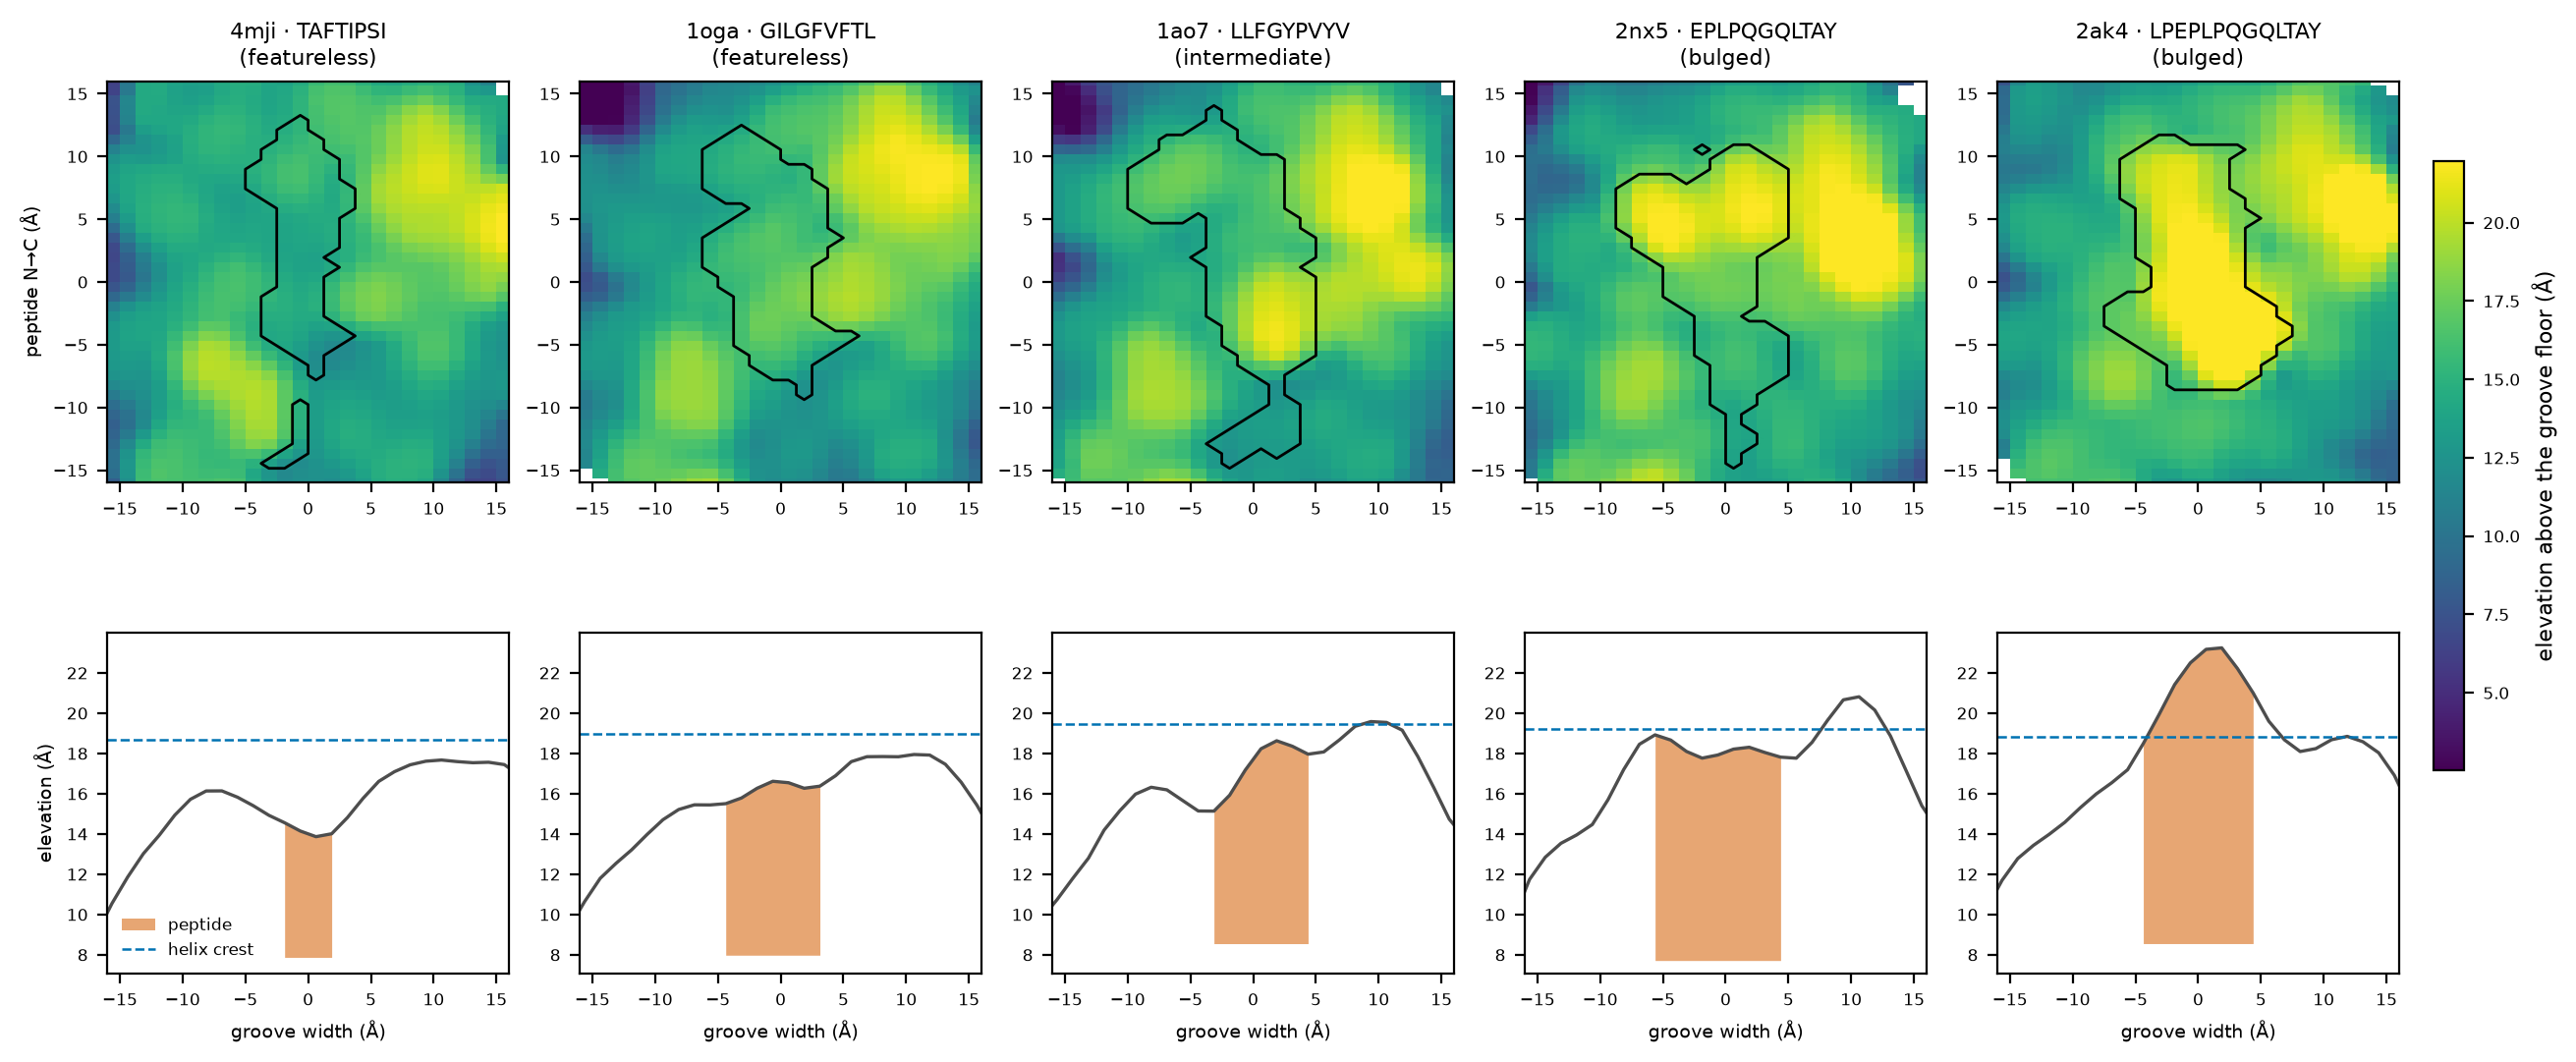

In [ ]:
# Loop variables are prefixed with _ so marimo scopes them to this cell; a bare `ax` at cell
# top level is a notebook-wide definition and collides with the next figure.
order = ["4mji", "1oga", "1ao7", "2nx5", "2ak4"]      # featureless -> bulged
_ms = [mapped(_p, grid=(grid_n.value, grid_n.value // 2), smooth=smooth.value) for _p in order]
_vmin, _vmax, _cmap = limits(_ms, channel.value)

_CHANNEL_LABEL = {"h": "elevation above the groove floor (Å)",
                  "phobic": "hydropathy (Kyte–Doolittle)", "charge": "formal charge"}
fig_main, _axes = plt.subplots(
    2, len(_ms), figsize=(2.6 * len(_ms), 5.6),
    gridspec_kw={"height_ratios": [1.9, 1.0], "hspace": 0.05}, constrained_layout=True)

_HELIX_CODES = [2, 3, 4]                              # mhc_helix_a1 / a2 / b1
for _col, (_pid, _m) in enumerate(zip(order, _ms)):
    _im = draw_map(_axes[0, _col], _m, channel.value, _vmin, _vmax, _cmap, SOURCE_CODES)
    _epitope, _label, _cite = CASES[_pid]
    _axes[0, _col].set_title(f"{_pid} · {_epitope}\n({_label})", fontsize=8)

    _ax = _axes[1, _col]
    _xs, _mean_h, _pep_frac = cross_profile(_m, SOURCE_CODES)
    _ok = np.isfinite(_mean_h)
    _ax.plot(_xs[_ok], _mean_h[_ok], color="0.3", lw=1.2)
    # Shade where the peptide owns the surface, and mark the helix crest it has to clear.
    _ax.fill_between(_xs, np.nanmin(_mean_h[_ok]), _mean_h, where=_pep_frac > 0.35,
                     color="#D55E00", alpha=0.55, lw=0, label="peptide")
    _is_helix = np.isin(_m.source, _HELIX_CODES) & np.isfinite(_m.channels["h"])
    if _is_helix.any():
        _crest = float(np.nanpercentile(_m.channels["h"][_is_helix], 90))
        _ax.axhline(_crest, color="#0072B2", ls="--", lw=0.9, label="helix crest")
    _ax.set_xlim(-16, 16)
    _ax.set_xlabel("groove width (Å)", fontsize=7)
    _ax.tick_params(labelsize=6)
    if _col == 0:
        _ax.set_ylabel("elevation (Å)", fontsize=7)
        _ax.legend(fontsize=6, loc="lower left", frameon=False)

# One shared elevation axis across the profile row, or the panels are not comparable.
_lo = min(_a.get_ylim()[0] for _a in _axes[1])
_hi = max(_a.get_ylim()[1] for _a in _axes[1])
for _a in _axes[1]:
    _a.set_ylim(_lo, _hi)
_axes[0, 0].set_ylabel("peptide N→C (Å)", fontsize=7)
# Span both rows so the colourbar does not steal width from the top row alone and leave the
# two rows misaligned.
_cb = fig_main.colorbar(_im, ax=_axes.ravel().tolist(), shrink=0.6, pad=0.015)
_cb.set_label(_CHANNEL_LABEL[channel.value], fontsize=8)
_cb.ax.tick_params(labelsize=6)
fig_main

Read the bottom row left to right — it is the one that settles it. Each panel cuts across
the groove and averages elevation over the peptide's own band; the orange fill is where the
peptide owns the surface, the dashed line is the MHC helix crest it would have to clear.

For the two featureless epitopes the orange sits in the valley **between** the two helix
rails and never reaches the dashed line: a TCR coming down meets mostly MHC. `1ao7`'s Tax
peptide pushes a single spike up (P5-Tyr). The two bulged EBV epitopes put the peptide
*at or above* the crest across the whole middle of the groove — that is the ridge of seven
solvent-exposed side chains the crystallographers describe.

Switch the channel control to `phobic` for the other half of why "featureless" is not just
"flat": the M1 peptide is greasy *and* buried, so what little of it shows reads hydrophobic,
while the bulged EBV epitopes present a polar, charged crest.

## The scalars, and how they rank

In [ ]:
stats = (surface_table([maps[p] for p in order])
         .with_columns(pl.col("structure.id")
                       .replace_strict({p: CASES[p][1] for p in CASES}).alias("literature"))
         .select("structure.id", "peptide", "literature", "relief", "peak_to_valley",
                 "frac_above_ridge", "phobic_centre")
         .with_columns(pl.col(c).round(3) for c in
                       ("relief", "peak_to_valley", "frac_above_ridge", "phobic_centre")))
stats

structure.id,peptide,literature,relief,peak_to_valley,frac_above_ridge,phobic_centre
str,str,str,f64,f64,f64,f64
"""4mji""","""TAFTIPSI""","""featureless""",0.946,4.514,0.0,-0.224
"""1oga""","""GILGFVFTL""","""featureless""",1.12,6.046,0.0,1.789
"""1ao7""","""LLFGYPVYV""","""intermediate""",2.232,9.36,0.149,-0.447
"""2nx5""","""EPLPQGQLTAY""","""bulged""",2.539,8.613,0.416,-1.288
"""2ak4""","""LPEPLPQGQLTAY""","""bulged""",2.716,10.95,0.758,-1.786


`frac_above_ridge` is the one that reads as a definition: the share of peptide surface
clearing the MHC helix crest. It is **exactly 0** for both featureless epitopes — no part
of them reaches the rim — and 0.42–0.75 for the bulged ones.

Over all 374 Canonical2026 complexes (230 distinct epitopes) the named cases land where
they should: `LPEPLPQGQLTAY` **2nd**, `HPVGEADYFEY` (HCMV pp65, also called bulged) **5th**,
`EPLPQGQLTAY` **8th**; `GILGFVFTL` 139th and `TAFTIPSI` 205th, both at 0.000. Five of the
eight most-protruding epitopes in the whole set are literature-named bulged HLA-B\*35
epitopes.

With two distinct epitopes per group that comparison is a 2-vs-2, so the properly-powered
evidence is the length trend across all 279 class-I structures: `frac_above_ridge` rises
0.054 (8-mers) → 0.569 (13-mers), Spearman on `relief` +0.414, p = 5.5e-13.

## Do maps of the same epitope look alike?

The map is only useful for comparing epitopes if two structures of the *same* epitope come
out closer to each other than to a different one. `surface_distance` is SURFMAP's Manhattan
map metric, normalised over the cells both maps reached.

In [ ]:
REPLICATES = {
    "GILGFVFTL": ["1oga", "2vlj", "5isz", "5tez"],
    "LPEPLPQGQLTAY": ["2ak4", "3kxf", "4jrx", "4jry"],
    "ELAGIGILTV": ["3hg1", "3qdg", "4jff", "5nht"],
}
rep_ids = [p for v in REPLICATES.values() for p in v]
rep_lab = np.array([k for k, v in REPLICATES.items() for _ in v])
rep_maps = [mapped(p) for p in rep_ids]
_ids, dmat = surface_distance(rep_maps, channel="h")

same = rep_lab[:, None] == rep_lab[None, :]
off = ~np.eye(len(rep_ids), dtype=bool)
within, between = dmat[same & off], dmat[~same & off]
dist_summary = pl.DataFrame({
    "comparison": ["same epitope", "different epitope"],
    "n_pairs": [int(np.isfinite(within).sum()), int(np.isfinite(between).sum())],
    "mean map distance": [round(float(np.nanmean(within)), 3),
                          round(float(np.nanmean(between)), 3)],
})
dist_summary

comparison,n_pairs,mean map distance
str,i64,f64
"""same epitope""",36,0.939
"""different epitope""",96,1.775


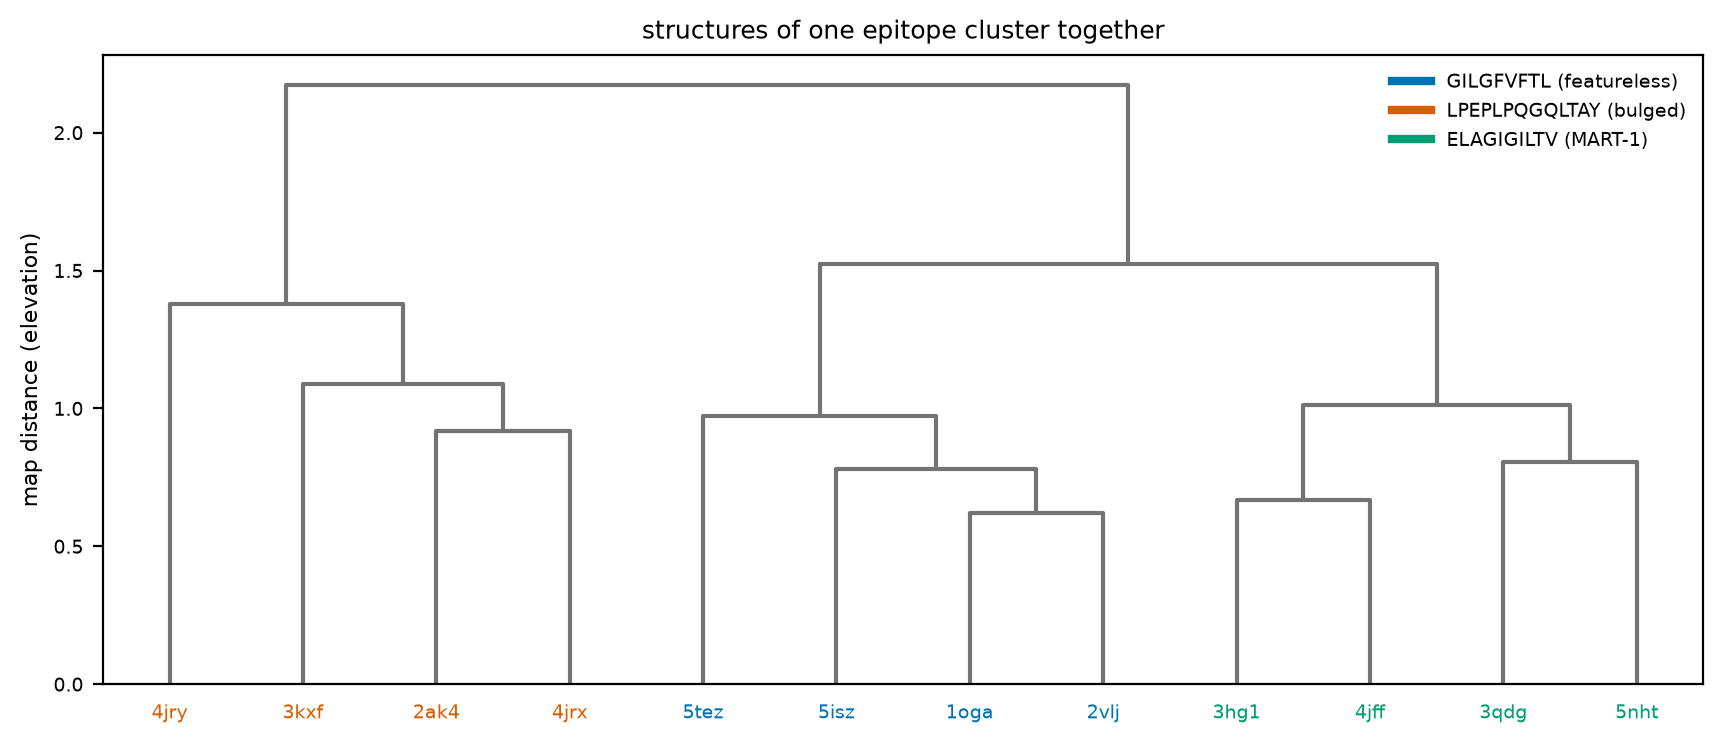

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

fig_tree, ax_tree = plt.subplots(figsize=(8.5, 3.6), constrained_layout=True)
# Branches neutral, leaves coloured by epitope: scipy tints clusters from its own palette,
# which would put a GILGFVFTL clade in the colour this figure's legend assigns to MART-1.
dendrogram(linkage(squareform(dmat, checks=False), method="complete"),
           labels=list(rep_ids), ax=ax_tree, link_color_func=lambda _k: "0.45")
ax_tree.set_ylabel("map distance (elevation)", fontsize=8)
ax_tree.tick_params(labelsize=7)
ax_tree.set_title("structures of one epitope cluster together", fontsize=9)
# Colour each leaf by its epitope rather than crowding the sequence into the tick label.
_EP_COLOUR = {"GILGFVFTL": "#0072B2", "LPEPLPQGQLTAY": "#D55E00", "ELAGIGILTV": "#009E73"}
_by_id = dict(zip(rep_ids, rep_lab))
for _t in ax_tree.get_xticklabels():
    _t.set_color(_EP_COLOUR[_by_id[_t.get_text()]])
_handles = [plt.Line2D([], [], color=_c, lw=3, label=_e) for _e, _c in
            (("GILGFVFTL (featureless)", "#0072B2"),
             ("LPEPLPQGQLTAY (bulged)", "#D55E00"),
             ("ELAGIGILTV (MART-1)", "#009E73"))]
ax_tree.legend(handles=_handles, fontsize=7, frameon=False, loc="upper right")
fig_tree

## Any structure you like

Everything above is `tcren.surface` with no notebook-only code, so point it at your own
model. `tcren surface -s models/ -o surface.csv --compare dist.csv --svg figs/` does the
same from the command line, and `tcren.viz.surface2d.render_surface_map` writes the SVG
version of these panels (hand-built, no matplotlib, every cell carrying its values as
`data-*` attributes).

In [ ]:
pdb_input = mo.ui.text(value="1ao7", label="Canonical2026 id")
pdb_input

&lt;marimo-text data-initial-value=&#x27;&amp;quot;1ao7&amp;quot;&#x27; data-label=&#x27;&amp;quot;&amp;#92;u003cspan class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;#92;u003e&amp;#92;u003cspan class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;#92;u003eCanonical2026 id&amp;#92;u003c/span&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;quot;&#x27; data-placeholder=&#x27;&amp;quot;&amp;quot;&#x27; data-kind=&#x27;&amp;quot;text&amp;quot;&#x27; data-full-width=&#x27;false&#x27; data-disabled=&#x27;false&#x27; data-debounce=&#x27;true&#x27;&gt;&lt;/marimo-text&gt;

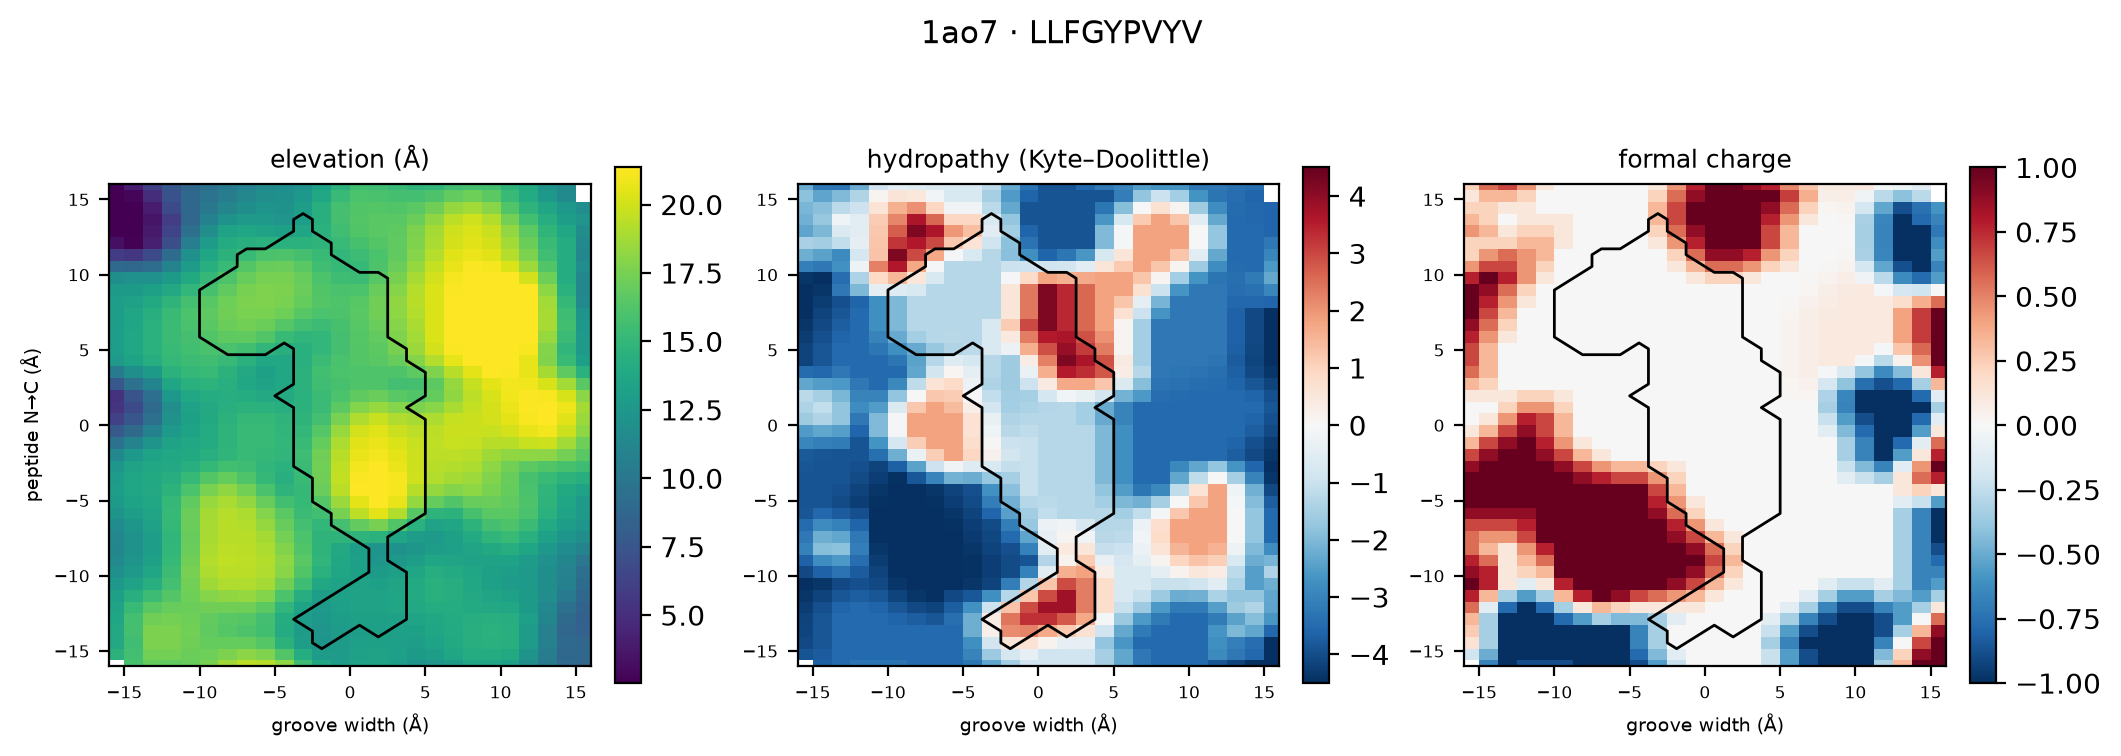

In [ ]:
try:
    m_free = mapped(pdb_input.value.strip())
    fig_free, _axs = plt.subplots(1, 3, figsize=(10.5, 3.9), constrained_layout=True)
    _TITLES = {"h": "elevation (Å)", "phobic": "hydropathy (Kyte–Doolittle)",
               "charge": "formal charge"}
    for _ax, _chan in zip(_axs, ("h", "phobic", "charge")):
        _lo, _hi, _cmap = limits([m_free], _chan)
        _im = draw_map(_ax, m_free, _chan, _lo, _hi, _cmap, SOURCE_CODES)
        _ax.set_title(_TITLES[_chan], fontsize=9)
        _ax.set_xlabel("groove width (Å)", **LABEL_KW)
        plt.colorbar(_im, ax=_ax, shrink=0.72)
    _axs[0].set_ylabel("peptide N→C (Å)", **LABEL_KW)
    fig_free.suptitle(f"{m_free.structure_id} · {m_free.peptide}", fontsize=11)
    out_free = fig_free
    stats_free = {k: round(v, 3) for k, v in surface_stats(m_free).items()}
except Exception as exc:                       # noqa: BLE001 - a bad id is user input, not a bug
    out_free, stats_free = f"{type(exc).__name__}: {exc}", {}
out_free

In [ ]:
stats_free